In [1]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform
from sklearn.metrics import classification_report, f1_score

import pandas as pd
import numpy as np
import joblib

import shap

c:\Users\user\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
X_train_others = pd.read_parquet('X_train_others.parquet')
y_train_others = pd.read_parquet('y_train_others.parquet')
X_train_others_smote = pd.read_parquet('X_train_others_smote.parquet')
y_train_others_smote = pd.read_parquet('y_train_others_smote.parquet')
X_val_others = pd.read_parquet('X_val_others.parquet')
y_val_others = pd.read_parquet('y_val_others.parquet')
X_test_others = pd.read_parquet('X_test_others.parquet')
y_test_others = pd.read_parquet('y_test_others.parquet')

In [ ]:
# Hyperparameter distributions
param_dist = {
    "n_estimators": randint(100, 500),
    "max_depth": randint(3, 8),
    "learning_rate": uniform(0.02, 0.13),      # 0.02 - 0.15
    "subsample": uniform(0.7, 0.3),            # 0.70 - 1.00
    "colsample_bytree": uniform(0.7, 0.3),     # 0.70 - 1.00
    "min_child_weight": randint(1, 7),
    "gamma": uniform(0, 2),
    "reg_alpha": uniform(0, 1),
    "reg_lambda": uniform(0.5, 2),
    "scale_pos_weight": [1, 2, 5, 10]                   # use 1 for normal data
}

In [5]:
# Base model
xgb = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)


random_xgb = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=100,
    scoring="f1",
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-2
)

# Train
random_xgb.fit(X_train_others, y_train_others)

# Best model
best_xgb = random_xgb.best_estimator_

print("Best parameters:")
print(random_xgb.best_params_)

print("Best CV F1-score:")
print(random_xgb.best_score_)

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best parameters:
{'colsample_bytree': np.float64(0.6977412621858619), 'gamma': np.float64(2.491238489244701), 'learning_rate': np.float64(0.10580105957146504), 'max_depth': 3, 'min_child_weight': 1, 'n_estimators': 536, 'reg_alpha': np.float64(0.20356494524080748), 'reg_lambda': np.float64(0.9585774175529961), 'scale_pos_weight': 5, 'subsample': np.float64(0.7951239203234952)}
Best CV F1-score:
0.2963915511310647


Save the model

In [6]:
joblib.dump(best_xgb, 'best_xgb.pkl')

['best_xgb.pkl']

Find the best threshold

In [7]:
val_prob = best_xgb.predict_proba(X_val_others)[:, 1]

thresholds = np.arange(0.05, 1.00, 0.05)

best_threshold = 0.5
best_f1 = 0

for t in thresholds:
    pred = (val_prob >= t).astype(int)
    score = f1_score(y_val_others, pred)

    if score > best_f1:
        best_f1 = score
        best_threshold = t

print("Best threshold:", best_threshold)
print("Validation F1:", best_f1)

Best threshold: 0.45
Validation F1: 0.29658587438102685


Test on the test dataset

In [8]:
test_prob = best_xgb.predict_proba(X_test_others)[:, 1]

test_pred = (test_prob >= best_threshold).astype(int)

print(classification_report(y_test_others, test_pred))

              precision    recall  f1-score   support

           0       0.95      0.87      0.91     56538
           1       0.23      0.44      0.31      4965

    accuracy                           0.84     61503
   macro avg       0.59      0.66      0.61     61503
weighted avg       0.89      0.84      0.86     61503



### Feature importance with SHAP

In [ ]:
xgb_model = joblib.load('models/best_xgb_sm.pkl')

In [10]:
print(xgb_model.get_booster().feature_names)

['flag_own_car', 'flag_own_realty', 'cnt_children', 'amt_income_total', 'amt_credit', 'amt_annuity', 'region_population_relative', 'days_birth', 'days_employed', 'days_registration', 'days_id_publish', 'own_car_age', 'flag_mobil', 'flag_work_phone', 'flag_cont_mobile', 'flag_phone', 'flag_email', 'cnt_fam_members', 'region_rating_client_w_city', 'hour_appr_process_start', 'reg_region_not_live_region', 'reg_city_not_live_city', 'ext_source_1', 'ext_source_2', 'ext_source_3', 'basementarea_avg', 'years_beginexpluatation_avg', 'years_build_avg', 'commonarea_avg', 'elevators_avg', 'entrances_avg', 'floorsmax_avg', 'floorsmin_avg', 'landarea_avg', 'livingapartments_avg', 'livingarea_avg', 'nonlivingapartments_avg', 'nonlivingarea_avg', 'totalarea_mode', 'obs_60_cnt_social_circle', 'def_60_cnt_social_circle', 'days_last_phone_change', 'flag_document_2', 'flag_document_3', 'flag_document_4', 'flag_document_5', 'flag_document_6', 'flag_document_7', 'flag_document_8', 'flag_document_9', 'flag_d

In [11]:
print(type(X_test_others))
print(X_test_others.columns[:10])

<class 'pandas.DataFrame'>
Index(['flag_own_car', 'flag_own_realty', 'cnt_children', 'amt_income_total',
       'amt_credit', 'amt_annuity', 'region_population_relative', 'days_birth',
       'days_employed', 'days_registration'],
      dtype='str')


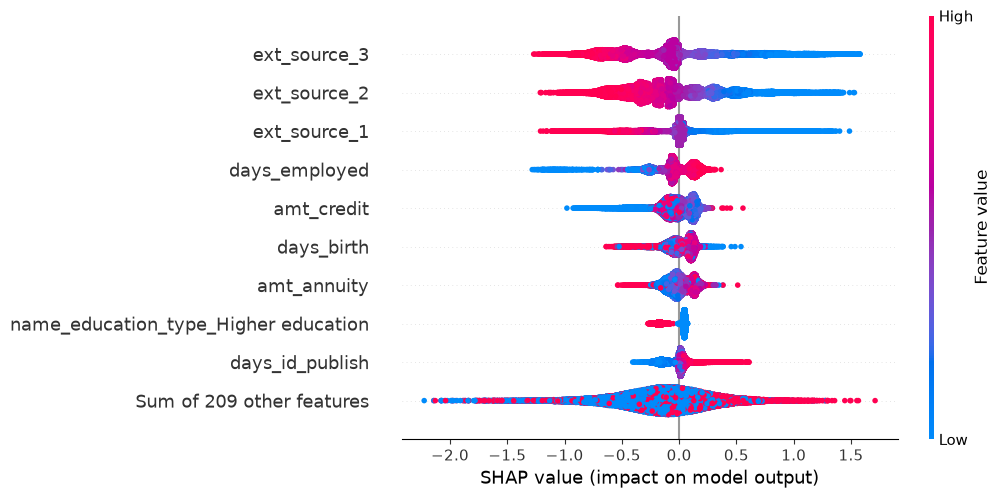

In [ ]:
explainer = shap.Explainer(xgb_model)
shap_values = explainer(X_test_others)

shap.plots.beeswarm(shap_values)

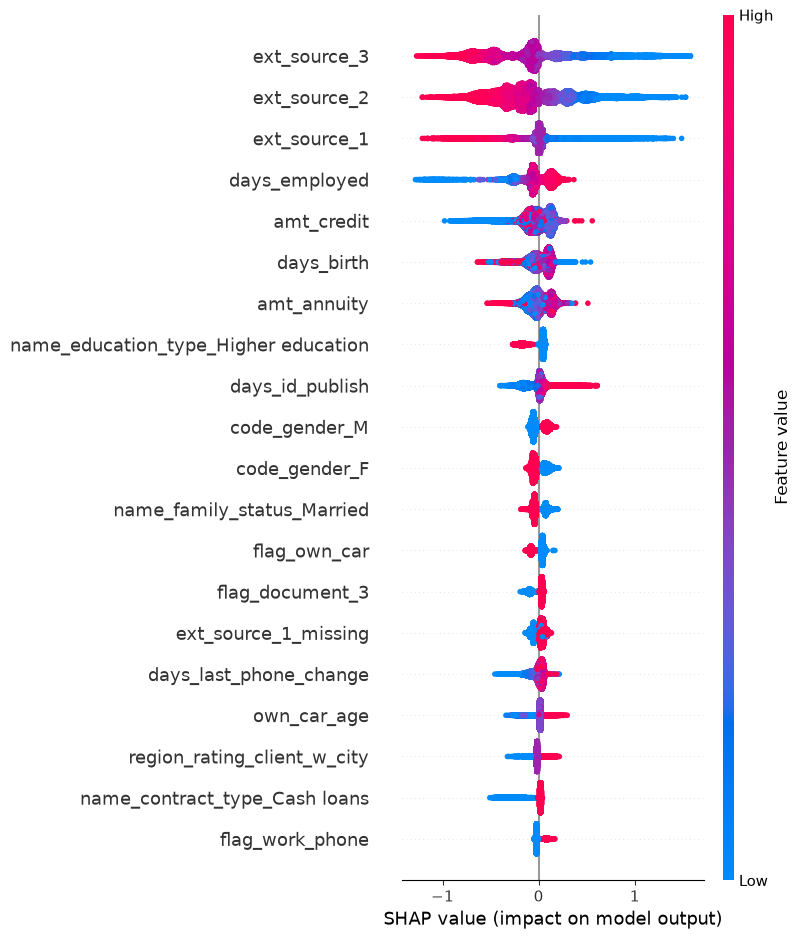

In [14]:
shap.summary_plot(shap_values)

### Train on SMOTE data

In [3]:
# Hyperparameter distributions
# scale_pos_weight is set to 1 for SMOTE data since the data is balanced after oversampling
from scipy.stats import randint, uniform

param_dist_sm = {
    "n_estimators": randint(100, 500),
    "max_depth": randint(3, 8),
    "learning_rate": uniform(0.02, 0.13),      # 0.02 - 0.15
    "subsample": uniform(0.7, 0.3),            # 0.70 - 1.00
    "colsample_bytree": uniform(0.7, 0.3),     # 0.70 - 1.00
    "min_child_weight": randint(1, 7),
    "gamma": uniform(0, 2),
    "reg_alpha": uniform(0, 1),
    "reg_lambda": uniform(0.5, 2)
}

In [4]:
# Base model
xgb_sm = XGBClassifier(
    objective="binary:logistic",
        tree_method="hist",
        device="cuda",
        eval_metric="logloss",
        random_state=12,
        n_jobs=1
)


random_xgb_sm = RandomizedSearchCV(
    estimator=xgb_sm,
    param_distributions=param_dist_sm,
    n_iter=75,
    scoring="f1",
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=1
)

# Train
random_xgb_sm.fit(X_train_others_smote, y_train_others_smote)

# Best model
best_xgb_sm = random_xgb_sm.best_estimator_

print("Best parameters:")
print(random_xgb_sm.best_params_)

print("Best CV F1-score:")
print(random_xgb_sm.best_score_)

Fitting 3 folds for each of 75 candidates, totalling 225 fits


c:\Users\user\AppData\Local\Programs\Python\Python314\Lib\site-packages\xgboost\core.py:553: UserWarning: [18:06:43] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


[CV] END colsample_bytree=0.8123620356542087, gamma=1.9014286128198323, learning_rate=0.11515921243548267, max_depth=7, min_child_weight=5, n_estimators=202, reg_alpha=0.44583275285359114, reg_lambda=0.6999498316360058, subsample=0.8377746675897602; total time=  14.0s
[CV] END colsample_bytree=0.8123620356542087, gamma=1.9014286128198323, learning_rate=0.11515921243548267, max_depth=7, min_child_weight=5, n_estimators=202, reg_alpha=0.44583275285359114, reg_lambda=0.6999498316360058, subsample=0.8377746675897602; total time=  18.3s
[CV] END colsample_bytree=0.8123620356542087, gamma=1.9014286128198323, learning_rate=0.11515921243548267, max_depth=7, min_child_weight=5, n_estimators=202, reg_alpha=0.44583275285359114, reg_lambda=0.6999498316360058, subsample=0.8377746675897602; total time=  18.4s
[CV] END colsample_bytree=0.8001125833417065, gamma=0.28573363584388156, learning_rate=0.10461550148335089, max_depth=7, min_child_weight=2, n_estimators=443, reg_alpha=0.8324426408004217, reg_

Save the model

In [ ]:
joblib.dump(best_xgb_sm, 'models/best_xgb_sm.pkl')

['best_xgb_sm.pkl']

Find the best threshold

In [6]:
val_prob = best_xgb_sm.predict_proba(X_val_others)[:, 1]

thresholds = np.arange(0.05, 1.00, 0.05)

best_threshold_sm = 0.5
best_f1_sm = 0

for t in thresholds:
    pred_sm = (val_prob >= t).astype(int)
    score_sm = f1_score(y_val_others, pred_sm)

    if score_sm > best_f1_sm:
        best_f1_sm = score_sm
        best_threshold_sm = t

print("Best threshold:", best_threshold_sm)
print("Validation F1:", best_f1_sm)

Best threshold: 0.15000000000000002
Validation F1: 0.2907613202852878


Test on the test data

In [7]:
test_prob_sm = best_xgb_sm.predict_proba(X_test_others)[:, 1]

test_pred_sm = (test_prob_sm >= best_threshold_sm).astype(int)

print(classification_report(y_test_others, test_pred_sm))

              precision    recall  f1-score   support

           0       0.95      0.86      0.90     56538
           1       0.22      0.44      0.29      4965

    accuracy                           0.83     61503
   macro avg       0.58      0.65      0.60     61503
weighted avg       0.89      0.83      0.85     61503



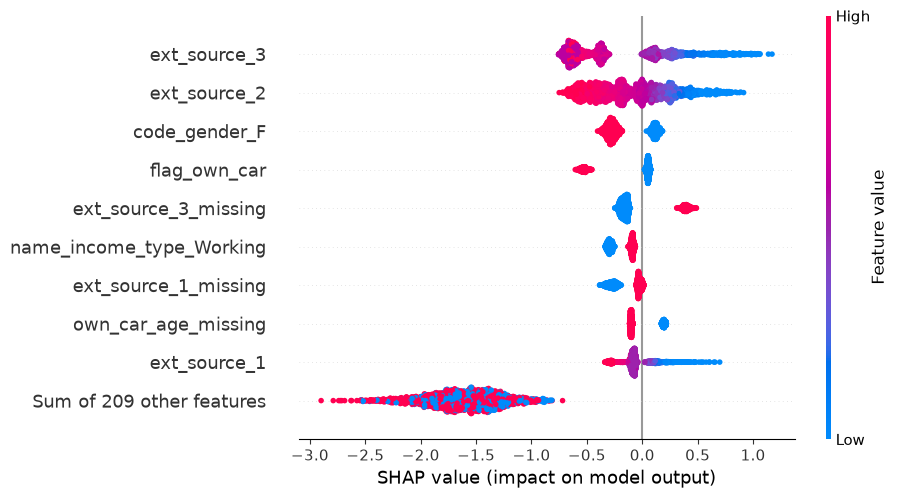

In [11]:
# Sample the test set for faster SHAP computation
X_sample = X_test_others.sample(n=2000, random_state=42)

explainer_sm = shap.TreeExplainer(best_xgb_sm)
shap_values_sm = explainer_sm(X_sample)

shap.plots.beeswarm(shap_values_sm)